<div align="center">

<h1>CSC 535 — Homework 1</h1>  
<b>August 29, 2025</b>  
<br>  
<b>Sungmin Ji</b>

</div>

# Problem 1

We have a random sample of 10 Bernoulli trials with success probability \( p = 0.5 \).

Let  
$$
X_i \overset{\text{iid}}{\sim} \text{Bernoulli}(0.5), \quad i = 1, \dots, 10
$$


## a)

The number of heads is equal to the number of tails when the number of successes is 5:

$$
\sum_{i=1}^{10} X_i = 5
$$

The probability of this event is given by the binomial formula:

$$
\mathbb{P} \left( \sum_{i=1}^{10} X_i = 5 \right) = \binom{10}{5} \left( \frac{1}{2} \right)^{10}
$$

## b)
The number of heads is greater than the number of tails when the number of successes is greater than 5:

$$
\sum_{i=1}^{10} X_i > 5
$$

The probability of this event is given by the binomial formula:

$$
\mathbb{P} \left( \sum_{i=1}^{10} X_i > 5\right) = \sum^{10}_{x=6} \binom{10}{x} \left( \frac{1}{2} \right)^{10}
$$

## c)

The result of $i$th flip is symmetric with $11-i$th flip is:

$$
X_i = X_{11-i},\quad i=1,2,3,4,5
$$
The probability is given by the independent property:
$$
\mathbb{P} \left( X_i = X_{11-i},\quad i=1,2,3,4,5 \right) = \prod^5_{i=1}\mathbb{P} \left( X_i = X_{11-i}\right)
$$
By the fact that $X_i, X_{11-i}$ follows an identical distribution for $i=1,\ldots,5$:

$$
\mathbb{P} \left( X_i = X_{11-i}\right) = \mathbb{P} \left( X_1 = X_{2}=1~\text{or}~X_1 = X_{2}=0\right) = \mathbb{P} \left( X_1 = X_{2}=1) + \mathbb{P}(X_1 = X_{2}=0\right)= 2\left(\frac{1}{2}\right)^2 = \frac{1}{2}
$$

Therefore,

$$
\mathbb{P} \left( X_i = X_{11-i},\quad i=1,2,3,4,5 \right) = \left(\frac{1}{2}\right)^5
$$

## d)

We define $a(n)$ as the number of binary sequences of length $n$ that do not contain 4 or more consecutive heads.

Since each sequence $(X_1, \ldots, X_{10})$ has equal probability, the probability of seeing at least four consecutive heads is:

$$
\mathbb{P}(\text{at least 4 consecutive heads in } (X_1, \ldots, X_{10})) = 1 - \mathbb{P}(\text{not contain 4 or more consecutive heads in } (X_1, \ldots, X_{10})) = 1 - \frac{a(10)}{\# \{ (X_1, \ldots, X_{10})\}} = 1- \frac{a(10)}{2^{10}}
$$


To define $a(n)$ recursively, we consider how a valid sequence of length $n$ (i.e., no 4 consecutive heads) can be constructed:

- If the sequence ends in a tail (T), we can append it to any valid sequence of length $n - 1$, contributing $a(n-1)$ possibilities.
- If the sequence ends in one, two, or three heads (H), it must be preceded by a tail. So we can append:
  - $TH$ to any valid sequence of length $n-1$: contributes $a(n-2)$
  - $THH$ to any valid sequence of length $n-2$: contributes $a(n-3)$
  - $THHH$ to any valid sequence of length $n-3$: contributes $a(n-4)$

This leads to the recurrence relation:

$$
a(n) = a(n - 1) + a(n - 2) + a(n - 3) + a(n - 4)
$$

with base cases:

$$
\begin{align*}
a(0) &= 1 \quad \text{(empty sequence)} \\
a(1) &= 2 \quad \text{(H, T)} \\
a(2) &= 4 \quad \text{(all 2-flip sequences valid)} \\
a(3) &= 8 \quad \text{(all 3-flip sequences valid)}
\end{align*}
$$

We can now compute $a(10)$ numerically.

In [32]:
# Count number of sequences with no 4 consecutive heads
def count_valid_sequences(n):
    a = [0] * (n + 1)
    a[0] = 1  # empty sequence
    if n >= 1: a[1] = 2
    if n >= 2: a[2] = 4
    if n >= 3: a[3] = 8
    if n >= 4: a[4] = 15  # all except 'HHHH'
    for i in range(5, n+1):
      a[i] = a[i-1] + a[i-2] + a[i-3] + a[i-4]
    return a[n]

# Total possible sequences
n = 10
total = 2 ** n
valid = count_valid_sequences(n)
at_least_4_heads = total - valid
probability = at_least_4_heads / total

print(f"Number of sequences with at least 4 consecutive heads: {at_least_4_heads}")
print(f"Probability: {probability:.5f}")

Number of sequences with at least 4 consecutive heads: 251
Probability: 0.24512


# Problem 2

##a )

Let $\Omega$ be the sample space for rolling two fair six-sided dice, and let $X_1(\omega)$ and $X_2(\omega)$ denote the outcomes of the first and second die, respectively, where $ X_1, X_2 \in \{1, \ldots, 6\} $.

Since each die has 6 possible outcomes and the rolls are independent, the total number of possible outcomes is:

$$
\# \{ X_1(\omega) : \omega \in \Omega \} \times \# \{ X_2(\omega) : \omega \in \Omega \} = 6 \times 6 = 36
$$

There is only **1** outcome.  The exact probability is:

$$
\mathbb{P}(X_1 + X_2=2) = \frac{1}{36} \approx 0.02778
$$

## b)


In [33]:
import numpy as np

# Set seed
np.random.seed(0)

# Simulate 1000 throws of two 6-sided dice
die1 = np.random.randint(1, 7, 1000)
die2 = np.random.randint(1, 7, 1000)
sums = die1 + die2

# Calculate empirical probability
empirical_prob = np.mean(sums == 2)
print(f"Empirical probability of sum = 2: {empirical_prob:.5f}")

Empirical probability of sum = 2: 0.02900


## c)

In [34]:
# Repeat simulation 10 times with the same seed
results = []

for i in range(10):
  np.random.seed(i)
  die1 = np.random.randint(1, 7, 1000)
  die2 = np.random.randint(1, 7, 1000)
  sums = die1 + die2
  prob = np.mean(sums == 2)
  results.append(prob)

# Print results
for i, prob in enumerate(results, 1):
    print(f"Run {i}: Empirical probability of sum = 2: {prob:.5f}")

Run 1: Empirical probability of sum = 2: 0.02900
Run 2: Empirical probability of sum = 2: 0.02400
Run 3: Empirical probability of sum = 2: 0.02000
Run 4: Empirical probability of sum = 2: 0.02300
Run 5: Empirical probability of sum = 2: 0.03400
Run 6: Empirical probability of sum = 2: 0.03200
Run 7: Empirical probability of sum = 2: 0.02800
Run 8: Empirical probability of sum = 2: 0.04000
Run 9: Empirical probability of sum = 2: 0.01900
Run 10: Empirical probability of sum = 2: 0.03400


## d)

Since the random sample consists of finite observations, the empirical probability will vary from one simulation to another, while the true probability of the event remains fixed and constant.

# Problem 3

## a)

Since the event \( A = 3, B = 3 \) is one of the outcomes contributing to the event \( S = 6 \), where \( S = A + B \), and \( S = 6 \) includes outcomes of the form \( A = i, B = 6 - i \) for \( i = 1, 2, 3, 4, 5 \), we have:

$$
\mathbb{P}(A = 3, B = 3 \mid S = 6) = \frac{\mathbb{P}(A = 3, B = 3, S = 6)}{\mathbb{P}(S = 6)} = \frac{\mathbb{P}(A = 3, B = 3)}{\mathbb{P}(S = 6)} = \frac{\mathbb{P}(A = 3) \cdot \mathbb{P}(B = 3)}{\mathbb{P}(S = 6)} = \frac{\frac{1}{6} \cdot \frac{1}{6}}{\frac{5}{36}} = \frac{1}{5}
$$

---

## b)

Since \( A = 3, B = 3 \) implies \( S = 6 \), we have:

$$
\mathbb{P}(S = 6 \mid A = 3, B = 3) = \frac{\mathbb{P}(A = 3, B = 3, S = 6)}{\mathbb{P}(A = 3, B = 3)} = \frac{\mathbb{P}(A = 3, B = 3)}{\mathbb{P}(A = 3, B = 3)} = 1
$$

---

## c)

The event \( A = 1, B = 1 \) is mutually exclusive with \( S = 6 \), since \( 1 + 1 \neq 6 \). Therefore:

$$
\mathbb{P}(A = 1, B = 1 \mid S = 6) = \frac{\mathbb{P}(A = 1, B = 1, S = 6)}{\mathbb{P}(S = 6)} = \frac{0}{\mathbb{P}(S = 6)} = 0
$$

---

## d)

The event \( S = 2 \) implies \( A = 1 \), since it is the only possible pair that sums to 2. Therefore:

$$
\mathbb{P}(A = 1 \mid S = 2) = \frac{\mathbb{P}(A = 1, S = 2)}{\mathbb{P}(S = 2)} = \frac{\mathbb{P}(S = 2)}{\mathbb{P}(S = 2)} = 1
$$

---

## e)

The total number of outcomes with \( A + B = 6 \) is 5, out of 36 total possible dice rolls. So:

$$
\mathbb{P}(S = 6) = \frac{5}{36}
$$


# Problem 4

## a)

We define the gaussian pdf:

$$
\phi(x|\mu, \sigma^2) = \frac{1}{ \sqrt{2\pi} \sigma} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2} \right),\quad x \in \mathbb R
$$
, where $\mu=70, \sigma=2$.

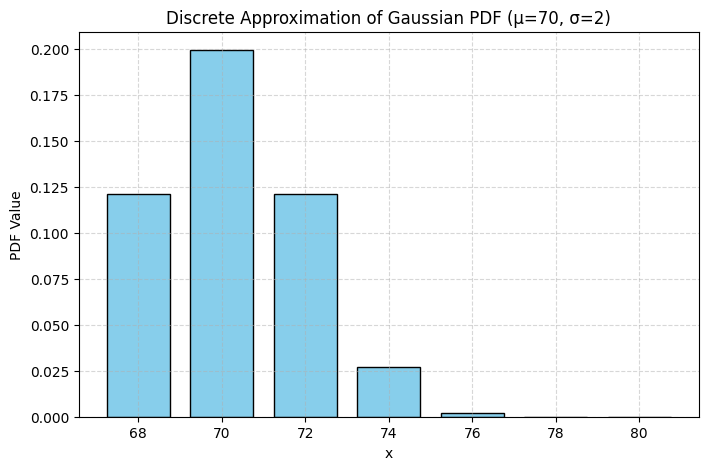

In [35]:
import matplotlib.pyplot as plt

# Parameters
mu = 70
sigma = 2

# Generate an array x
delta_x = 2 # increment of the array x
x = np.arange(68, 80+delta_x, delta_x)

# Gaussian PDF
def gaussian_pdf(x, mu, sigma):
  coef = 1 / (np.sqrt(2 * np.pi)*sigma)
  exponent = -((x-mu)**2) / (2 * sigma**2)
  return coef * np.exp(exponent)

# Evaluate the PDF at each x
p = gaussian_pdf(x, mu, sigma)

# Plot as a bar chart
plt.figure(figsize=(8, 5))

plt.bar(x, p, width=1.5, color="skyblue", edgecolor="black")
plt.title("Discrete Approximation of Gaussian PDF (μ=70, σ=2)")
plt.xlabel("x")
plt.ylabel("PDF Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## b)

We find an integral:

$$
\mathbb P(68 < X \leq 80) = \int^{80}_{68}\phi(x|\mu, \sigma^2)\, dx
$$

The Riemann sum approximation is defined by:

$$
\sum^N_{i=1} \phi(x_i|\mu, \sigma^2)\, \delta(x)
$$
, where $N = \#\{x_i\}$ and $\delta x = \max_{1\leq i \leq N-1} |x_{i+1}-x_i|$.

In [36]:
# Find an integral using a Riemann sum.

integral_approx = np.sum(gaussian_pdf(x, mu, sigma)*delta_x)

print(f"Intergral approximation with the delta x = 2 : {integral_approx:.5f}")

Intergral approximation with the delta x = 2 : 0.94144


## c)

We reduce the space with $\delta x= 0.01$.

In [37]:
# Generate a finer grid for x with smaller spacing
delta_x_fine = 0.01
x_fine = np.arange(68, 80 + delta_x_fine, delta_x_fine)

# Approximate the integral of the Gaussian PDF over [68, 80]
integral_approx = np.sum(gaussian_pdf(x_fine, mu, sigma) * delta_x_fine)

print(f"Integral approximation over [68, 80] with Δx = {delta_x_fine}: {integral_approx:.5f}")


Integral approximation over [68, 80] with Δx = 0.01: 0.84195


The integral approximation has decreased compared to the previous coarser estimate. While the finer discretization improves accuracy, it also comes with the practical downside of increased computational cost.

## d)

In [38]:
x_wide = np.arange(20, 120 + delta_x_fine, delta_x_fine)

# PDF
p_wide = gaussian_pdf(x_wide, mu, sigma)

# Approximate the integral of the Gaussian PDF over [68, 80]
integral_approx = np.sum(p_wide * delta_x_fine)

# Print the approximation result
print(f"Approximate probability P(20 ≤ X < 120): {integral_approx:.10f}")

Approximate probability P(20 ≤ X < 120): 1.0000000000
